In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 
This notebook uses Logistic Regression as the baseline classification model and evaluates performance using multiple classification metrics.
Since churn prediction is a classification problem, metrics such as Precision, Recall and ROC-AUC are more informative than accuracy alone.

### Train Logistic Regression Model

In [3]:
import pandas as pd
df = pd.read_csv("data/customer_churn_dataset-training-master.csv")

X_train_scaled = pd.read_csv(
    "data/processed/X_train_scaled.csv"
)

X_test_scaled = pd.read_csv(
    "data/processed/X_test_scaled.csv"
)

y_train = pd.read_csv(
    "data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "data/processed/y_test.csv"
).squeeze()

In [4]:

log_model = LogisticRegression(
    random_state =42,
    max_iter = 1000
)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### 
A Logistic Regression model was trained using the scaled training data.

The maximum number of iterations was increased to ensure model convergence during optimization.

### Generate Predictions

In [5]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

### 
The model generated predicted churn classes as well as predicted probabilities of churn.
Probability estimates are useful for ranking customers according to churn risk.

### Accuracy

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,2))

Accuracy: 0.89


### 
Accuracy measures the proportion of customers correctly classified by
the model.

The Logistic Regression model correctly classified approximately 89% of
customers in the test dataset.

However, accuracy alone may be misleading in classification problems,
particularly when class distributions are imbalanced. Therefore,
additional metrics such as Precision, Recall, F1 Score and ROC-AUC were
also evaluated.

### Precision

In [7]:
precision = precision_score(y_test,y_pred)

print("Precision:", round(precision,2))

Precision: 0.92


### 
Precision measures the proportion of customers predicted to churn that
actually churned.
The Logistic Regression model achieved a precision of 92%, indicating
that most customers identified as potential churners were correctly
classified.A high precision reduces the number of false positives.

### Recall

In [8]:
recall = recall_score(y_test,y_pred)
print("Recall:", round(recall,2))

Recall: 0.89


### 
Recall measures the proportion of actual churners correctly identified
by the model.

The Logistic Regression model achieved a recall of 89%, indicating that
the model successfully identified the majority of customers who were
likely to leave the company.

### F1 Score

In [9]:
f1S = f1_score(y_test,y_pred)
print("F1 Score:",round(f1S,3))

F1 Score: 0.904


### 
The F1 score combines precision and recall into a single performance
metric and provides a balanced assessment of classification quality.
The Logistic Regression model achieved an F1 score of 0.904, indicating
a strong balance between correctly identifying churners and minimizing
false positive predictions.

### ROC-AUC

In [10]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", round(roc_auc,2))

ROC-AUC: 0.96


### 
ROC-AUC measures the model's ability to distinguish between customers
who churn and those who remain with the company across all possible
classification thresholds.

The Logistic Regression model achieved an ROC-AUC score of 0.96,
indicating excellent discriminative performance.

This suggests that the model is highly effective at ranking customers
according to their likelihood of churn.

###  Classification Report


In [11]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88     38167
         1.0       0.92      0.89      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



### 
The classification report provides precision, recall and F1 scores for
both churned and retained customers.

The Logistic Regression model performed well across both classes,
achieving precision, recall and F1 scores close to 90%.

For the churn class (1), the model achieved a precision of 92%, recall
of 89% and an F1 score of 90%, indicating strong performance in
identifying customers at risk of leaving the company.

### Confusion Matrix

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[34486  3681]
 [ 5729 44271]]


###

The confusion matrix summarises the model predictions and identifies true positives, true negatives, false positives and false negatives.
The model correctly identified 34,486 retained customers and 44,271 customers who churned.
The model incorrectly classified 3,681 retained customers as churners (false positives) and failed to identify 5,729 customers who actually churned (false negatives).
Overall, the model demonstrated strong predictive performance with relatively few classification errors.

### Confusion Matrix Visualization

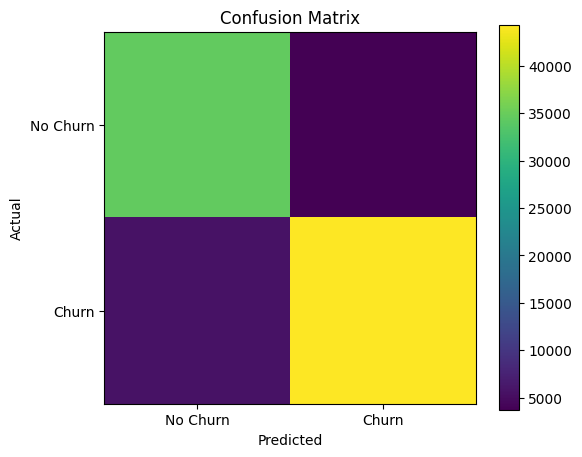

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.yticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### 
The confusion matrix visualization provides an intuitive representation of the model's prediction performance.

The large values along the diagonal indicate that the model correctly classified the majority of both churned and retained customers.

Reducing false negatives is particularly important in churn prediction,since failing to identify customers likely to leave may result in lost revenue and missed retention opportunities.

### Feature Importance

In [16]:
X_train_features = pd.read_csv(
    "data/processed/X_train_features.csv"
)

feature_importance = pd.DataFrame({
    "Feature": X_train_features.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute Importance
10,Contract Length_Monthly,4.522339,4.522339
3,Support Calls,2.304942,2.304942
5,Total Spend,-1.458486,1.458486
4,Payment Delay,0.926151,0.926151
7,Gender_Male,-0.569490,0.569490
6,Last Interaction,0.526083,0.526083
0,Age,0.445691,0.445691
1,Tenure,-0.136309,0.136309
2,Usage Frequency,-0.129120,0.129120
9,Subscription Type_Standard,-0.057839,0.057839


### 

Logistic Regression coefficients provide insight into the factors that
increase or decrease the likelihood of customer churn.

Because the positive class in my project was Churn = 1, positive coefficients increased the probability of customer churn, while negative coefficients reduced churn probability and were therefore associated with customer retention.

Contract Length_Monthly was the strongest positive predictor of churn,
indicating that customers on monthly contracts were substantially more
likely to leave than customers on longer-term contracts.

Support Calls and Payment Delay were also strong positive predictors,
suggesting that customer dissatisfaction and payment issues are important
drivers of churn.

Total Spend exhibited a strong negative coefficient, indicating that
higher-spending customers were less likely to leave the company.

Tenure and Usage Frequency also had negative coefficients, suggesting
that long-term and more engaged customers tend to exhibit greater
retention.

Overall, the model identified contract commitment, customer support
experience and customer value as the primary drivers of churn in this
dataset.